In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
import os

tf.config.list_physical_devices('GPU')

[]

# importing data

In [4]:
df = pd.read_csv('../camels_info/camels_parameters.csv')
df

,Name,Omega_m,sigma_8,A_SN1,A_AGN1,A_SN2,A_AGN2,seed
0,LH_0,0.3090,0.9790,3.11234,1.12194,0.66850,0.53182,0
1,LH_1,0.3026,0.9394,3.42001,3.96137,1.03311,1.16070,1
2,LH_2,0.4282,0.7530,0.70613,0.37423,1.96292,0.62720,2
3,LH_3,0.1906,0.6286,1.60882,0.39887,0.86634,0.86634,3
4,LH_4,0.1382,0.6874,1.19914,0.27586,0.82188,0.91700,4
...,...,...,...,...,...,...,...,...
1092,CV_26,0.3000,0.8000,1.00000,1.00000,1.00000,1.00000,27
1093,EX_0,0.3000,0.8000,1.00000,1.00000,1.00000,1.00000,13560
1094,EX_1,0.3000,0.8000,1.00000,100.00000,1.00000,1.00000,13560
1095,EX_2,0.3000,0.8000,100.00000,1.00000,1.00000,1.00000,13560


In [5]:
df.loc[df['Name'] == "LH_0"].values[0][1:-1]

array([0.309, 0.979, 3.11234, 1.12194, 0.6685, 0.53182], dtype=object)

In [6]:
out_dir = "../power_spectra/CO/20230313_no_std/"

def get_LH_files():
    fils = list(map(lambda fil: fil[:-4], \
               (filter(lambda fil: f"LH_" in fil, os.listdir(out_dir)))))
    sorter_1P_fils = lambda filname: int(filname.split('_')[-1].replace('n', '-'))
    return sorted(fils, key=sorter_1P_fils)

sim_names = get_LH_files()
sim_names[:5], sim_names[-5:], len(sim_names)

(['LH_0', 'LH_1', 'LH_2', 'LH_3', 'LH_4'],
 ['LH_995', 'LH_996', 'LH_997', 'LH_998', 'LH_999'],
 1000)

In [7]:
if "LH_603" in sim_names:
    sim_names.remove("LH_603")

In [8]:
non_nan_range = np.arange(24, 46)
all_curves = np.array([])
k_set = None
for fil in sim_names:
    with np.load(out_dir + fil + ".npz", allow_pickle=True) as data:
        curves = data['curves'].item()
        redshifts = data['redshifts'].item()
        ks = data['ks'].item()
    nan_sum = sum(sum(np.isnan(np.array(list(curves.values()))))[non_nan_range])
    assert (nan_sum == 0), fil
    assert (sum(np.isnan(np.array(list(curves.values()))))[23] == 34)
    assert (sum(np.isnan(np.array(list(curves.values()))))[46] == 34)
    if k_set is None:
        k_set = ks[0]
    for k in ks.values():
        assert((k == k_set).all()), print(fil, k, k_set)

In [70]:
sim_names = sim_names[:603] + ["LH_603"] + sim_names[604:]
sim_names[600:605]

['LH_600', 'LH_601', 'LH_602', 'LH_603', 'LH_605']

In [9]:
num_samples = len(sim_names)
print(num_samples)
non_nan_range = np.arange(24, 46)
all_curves = np.zeros((num_samples, 34, 22)) + np.nan
all_cosmologies = np.zeros((num_samples, 6)) + np.nan
for ind, fil in enumerate(sim_names):
    with np.load(out_dir + fil + ".npz", allow_pickle=True) as data:
        curves = data['curves'].item()
        redshifts = data['redshifts'].item()
        ks = data['ks'].item()
    all_curves[ind] = np.array(list(curves.values()))[:, non_nan_range]
    all_cosmologies[ind] = df.loc[df['Name'] == fil].values[0][1:-1]

999


In [10]:
print(all_curves.shape, all_cosmologies.shape)
print(np.sum(np.isnan(all_curves)), np.sum(np.isnan(all_cosmologies)))

(999, 34, 22) (999, 6)
0 0


In [11]:
train_split, val_split, test_split = int(0.7*num_samples), \
            int(0.15*num_samples) + 1, int(0.15*num_samples) + 1

print(train_split, val_split, test_split, train_split+val_split+test_split)

train_x, val_x, test_x = np.split(all_curves, [train_split, train_split+val_split])
train_y, val_y, test_y = np.split(all_cosmologies, [train_split, train_split+val_split])

print(train_x.shape, val_x.shape, test_x.shape)
print(train_y.shape, val_y.shape, test_y.shape)

699 150 150 999
(699, 34, 22) (150, 34, 22) (150, 34, 22)
(699, 6) (150, 6) (150, 6)


# Basic NN

In [12]:
# Define the input shape
input_shape = (34, 22, 1) 
# Define the model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=input_shape),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(6, activation='linear') # assuming 6 output parameters
])

# Compile the model
model.compile(loss='mse', optimizer='adam')

# Train the model
history = model.fit(train_x, train_y, epochs=50, validation_data=(val_x, val_y))

# Evaluate the model on the test set
test_loss = model.evaluate(test_x, test_y)
print('Test loss:', test_loss)

model.summary()

Epoch 1/50


2023-03-14 12:40:42.301241: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


22/22 [==============================] - 1s 22ms/step - loss: 219307.4375 - val_loss: 966.5001
Epoch 2/50
22/22 [==============================] - 0s 16ms/step - loss: 352.2562 - val_loss: 55.1278
Epoch 3/50
22/22 [==============================] - 0s 17ms/step - loss: 77.4761 - val_loss: 24.4706
Epoch 4/50
22/22 [==============================] - 0s 16ms/step - loss: 34.9523 - val_loss: 18.2840
Epoch 5/50
22/22 [==============================] - 0s 16ms/step - loss: 20.6105 - val_loss: 17.1532
Epoch 6/50
22/22 [==============================] - 0s 16ms/step - loss: 25.5048 - val_loss: 5.8522
Epoch 7/50
22/22 [==============================] - 0s 16ms/step - loss: 20.1024 - val_loss: 8.5855
Epoch 8/50
22/22 [==============================] - 0s 16ms/step - loss: 13.5979 - val_loss: 6.7567
Epoch 9/50
22/22 [==============================] - 0s 16ms/step - loss: 8.2066 - val_loss: 7.1014
Epoch 10/50
22/22 [==============================] - 0s 16ms/step - loss: 10.8575 - val_loss: 10.6315

5/5 [==============================] - 0s 2ms/step


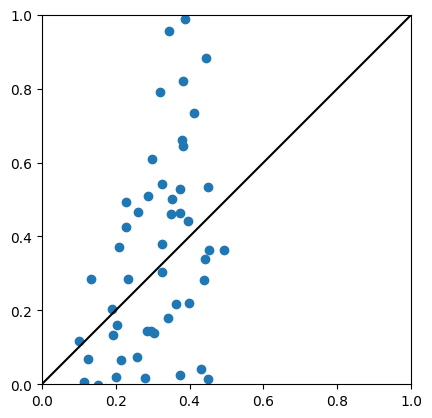

In [15]:
predictions = model.predict(test_x)
upp_lim = 1
plt.figure()
plt.scatter(test_y[:, 0], predictions[:, 0])
plt.plot([0, upp_lim], [0, upp_lim], color="black")
plt.xlim([0, upp_lim])
plt.ylim([0, upp_lim])
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.show()
plt.close()

# CNN

In [16]:
input_shape = (34, 22, 1) 

model = tf.keras.Sequential([
  tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
  tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
  tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
  tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(6, activation='linear') # assuming 6 output parameters
])

# Compile the model
model.compile(loss='mse', optimizer='adam')

# Train the model
history = model.fit(train_x, train_y, epochs=50, validation_data=(val_x, val_y))

# Evaluate the model on the test set
test_loss = model.evaluate(test_x, test_y)
print('Test loss:', test_loss)

model.summary()

Epoch 1/50
22/22 [==============================] - 1s 13ms/step - loss: 1084.0074 - val_loss: 61.6243
Epoch 2/50
22/22 [==============================] - 0s 10ms/step - loss: 37.6628 - val_loss: 17.7814
Epoch 3/50
22/22 [==============================] - 0s 9ms/step - loss: 19.5501 - val_loss: 12.7372
Epoch 4/50
22/22 [==============================] - 0s 9ms/step - loss: 13.8190 - val_loss: 8.9598
Epoch 5/50
22/22 [==============================] - 0s 9ms/step - loss: 10.7217 - val_loss: 7.7349
Epoch 6/50
22/22 [==============================] - 0s 9ms/step - loss: 7.6252 - val_loss: 6.8112
Epoch 7/50
22/22 [==============================] - 0s 9ms/step - loss: 6.6940 - val_loss: 8.4686
Epoch 8/50
22/22 [==============================] - 0s 9ms/step - loss: 6.1833 - val_loss: 5.2982
Epoch 9/50
22/22 [==============================] - 0s 9ms/step - loss: 5.1204 - val_loss: 5.2815
Epoch 10/50
22/22 [==============================] - 0s 9ms/step - loss: 4.6850 - val_loss: 4.6237
Epoch 1

5/5 [==============================] - 0s 2ms/step


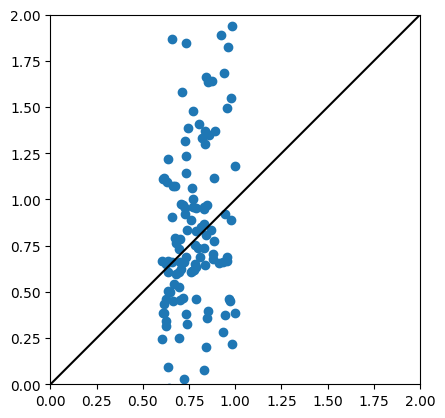

In [19]:
predictions = model.predict(test_x)
upp_lim = 2
plt.figure()
plt.scatter(test_y[:, 1], predictions[:, 1])
plt.plot([0, upp_lim], [0, upp_lim], color="black")
plt.xlim([0, upp_lim])
plt.ylim([0, upp_lim])
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.show()
plt.close()